<a href="https://colab.research.google.com/github/AlukweJonesTerah/ALGOS/blob/main/nssf_complete_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NSSF A3 Classifier Pipeline
### Download → Extract → Algorithm Sort → Train EfficientNet → ONNX Export

**Run order:** Execute cells top to bottom. Each step skips automatically if already done.

| Step | What it does |
|------|-------------|
| 1 | Install dependencies |
| 2 | Download archive from Google Drive |
| 3 | Extract archive |
| 4 | Algorithm sort → `Sorted_A3` / `Sorted_Other` (creates training labels) |
| 5 | Build train/val/test splits |
| 6 | Train EfficientNet-B0 |
| 7 | Tune decision threshold |
| 8 | Evaluate on test set |
| 9 | Export to ONNX |
| 10 | Hybrid classifier + full batch sort |

> Set runtime to **GPU** before starting: Runtime → Change runtime type → T4 GPU

---
## STEP 1 — Install dependencies

In [1]:
!pip install -q pillow pytesseract gdown py7zr onnx onnxruntime onnxscript
!apt-get install -q tesseract-ocr

import os, shutil, csv, random, json, zipfile, tarfile
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models

import onnx
import onnxruntime as ort
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 5.9 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Device  : cpu
PyTorch : 2.10.0+cpu


---
## STEP 2 — Download from Google Drive

In [2]:
import gdown

# ADD FILE IDs
# Key is Google Drive file ID ( can be found in the shared link url of your zipped folder)
# make sure url has public access to anyone
# Value is local destination path
FILES = {
    '1TB2GKpquFjK4Dhpk2fGhSJkRZ_Qujc48': '/content/nssfA3_.7z',
}

for fid, dest in FILES.items():
    if not fid:
        continue
    if os.path.exists(dest):
        size_gb = os.path.getsize(dest) / 1e9
        print(f'✅ Already downloaded: {os.path.basename(dest)} ({size_gb:.2f} GB) — skipping')
        continue
    print(f'Downloading {os.path.basename(dest)} ...')
    gdown.download(f'https://drive.google.com/uc?id={fid}', dest, quiet=False)
    print(f'✅ Saved to {dest}')

Downloading...
From (original): https://drive.google.com/uc?id=1TB2GKpquFjK4Dhpk2fGhSJkRZ_Qujc48
From (redirected): https://drive.google.com/uc?id=1TB2GKpquFjK4Dhpk2fGhSJkRZ_Qujc48&confirm=t&uuid=4b1b7d19-3b8c-48ba-83f6-689a04590f28
To: /content/nssfA3_.7z
100%|██████████| 460M/460M [00:06<00:00, 75.9MB/s]

✅ Saved to /content/nssfA3_.7z


---
## STEP 3 — Extract archive

In [3]:
def smart_extract(archive_path, dest_folder):
    """
    Extracts archive into dest_folder.
    Detects format by magic bytes (not file extension).
    """
    if not os.path.exists(archive_path):
        print(f'⚠  Not found: {archive_path}')
        return False

    os.makedirs(dest_folder, exist_ok=True)
    size_mb = os.path.getsize(archive_path) / 1e6

    with open(archive_path, 'rb') as f:
        magic = f.read(8)

    is_7z  = magic[:6] == b'7z\xbc\xaf\x27\x1c'
    is_zip = magic[:2] == b'PK'
    is_tar = magic[:2] == b'\x1f\x8b'

    print(f'Extracting {os.path.basename(archive_path)} ({size_mb:.0f} MB) → {dest_folder}')

    if is_7z:
        print('  Format: 7z')
        try:
            import py7zr
            with py7zr.SevenZipFile(archive_path, mode='r') as z:
                z.extractall(path=dest_folder)
            return True
        except Exception as e:
            print(f'  py7zr failed: {e}')
            return False

    elif is_zip:
        print('  Format: zip')
        with zipfile.ZipFile(archive_path, 'r') as z:
            members = z.namelist()
            top_levels = set(m.split('/')[0] for m in members if m.strip('/'))
            has_wrapper = (len(top_levels) == 1 and any(m.endswith('/') for m in members))
            if has_wrapper:
                parent = os.path.dirname(dest_folder)
                z.extractall(parent)
                inner = os.path.join(parent, list(top_levels)[0])
                if inner != dest_folder and os.path.exists(inner):
                    os.rename(inner, dest_folder)
            else:
                z.extractall(dest_folder)
        return True

    elif is_tar:
        print('  Format: tar.gz')
        with tarfile.open(archive_path, 'r:gz') as t:
            t.extractall(dest_folder)
        return True

    else:
        print(f'  Unknown format (magic: {magic[:6].hex()}) — trying zip...')
        try:
            with zipfile.ZipFile(archive_path, 'r') as z:
                z.extractall(dest_folder)
            return True
        except Exception as e:
            print(f'  Failed: {e}')
            return False


# Extract all archives
ARCHIVES = {
    '/content/nssfA3_.7z': '/content/nssfA3_',
}

EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

for archive, dest_root in ARCHIVES.items():
    if os.path.exists(dest_root) and len(os.listdir(dest_root)) > 0:
        all_imgs = list(Path(dest_root).rglob('*'))
        imgs = [f for f in all_imgs if f.suffix.lower() in EXTS]
        print(f'✅ Already extracted: {dest_root} ({len(imgs)} images found)')
    else:
        ok = smart_extract(archive, dest_root)
        if ok:
            imgs = [f for f in Path(dest_root).rglob('*') if f.suffix.lower() in EXTS]
            print(f'Done — {len(imgs)} images in {dest_root}')
        else:
            print('Extraction failed — check the archive')

Extracting nssfA3_.7z (460 MB) → /content/nssfA3_
  Format: 7z
Done — 483 images in /content/nssfA3_


In [4]:
def find_image_root(base_dir, exts=EXTS):
    """
    Walks base_dir and returns the deepest folder that contains
    the majority of images. Handles any nesting depth.
    """
    all_imgs = [f for f in Path(base_dir).rglob('*') if f.suffix.lower() in exts]
    if not all_imgs:
        return base_dir

    # Count images per folder
    folder_counts = Counter(str(f.parent) for f in all_imgs)
    # Return the folder with the most images
    return max(folder_counts, key=folder_counts.get)


SOURCE_DIR = find_image_root('/content/nssfA3_')
all_source_imgs = [f for f in Path(SOURCE_DIR).rglob('*') if f.suffix.lower() in EXTS]

print(f'Image source folder : {SOURCE_DIR}')
print(f'Total images found  : {len(all_source_imgs)}')

if len(all_source_imgs) == 0:
    print('No images found — check that extraction completed successfully')
else:
    print(f'   Sample files: {[f.name for f in all_source_imgs[:5]]}')

Image source folder : /content/nssfA3_/nssfA3_
Total images found  : 483
   Sample files: ['20001105.jpg', '10000250.jpg', '20003002.jpg', '900954620__10001033.jpg', '20001760.jpg']


---
## STEP 4 — Algorithm sort (creates the training labels)

The algorithm from v6 runs first and sorts images into `Sorted_A3` / `Sorted_Other`.
These sorted folders become the **ground truth labels** for training the ML model.

In [5]:
import pytesseract
from pytesseract import Output

# ── Algorithm v6 (all fixes included) ────────────────────────────────────────
PAPER_SIZES  = [('A3', 297.0), ('A4', 210.0), ('Letter/Legal', 215.9)]
TOLERANCE_MM = 18
DPI_TRUST    = 200
DPI_MIN      = 50
DPI_MAX      = 1200
STD_DPIS     = [96, 100, 120, 150, 200, 300, 400, 600]  # 100 & 120 added in v6

def _std_dist(dpi):
    return min(abs(dpi - s) for s in STD_DPIS)

def _implied_classify(short_px):
    cands = []
    for lbl, pmm in PAPER_SIZES:
        idpi = short_px / (pmm / 25.4)
        if DPI_MIN <= idpi <= DPI_MAX:
            cands.append((_std_dist(idpi), lbl, idpi))
    cands.sort()
    return (cands[0][1], cands[0][2]) if cands else (None, None)

def _get_rotation(img):
    try:
        osd = pytesseract.image_to_osd(
            img.convert('L'), output_type=Output.DICT, config='--psm 0'
        )
        return osd.get('rotate', 0) if osd.get('orientation_conf', 0) >= 2.0 else 0
    except Exception:
        return 0

def algorithm_classify(image_path, debug=False):
    """Returns (label, confidence, corrected_img, rotation_deg)."""
    try:
        with Image.open(image_path) as img:
            angle = _get_rotation(img)
            img_c = img.rotate(-angle, expand=True) if angle else img.copy()
            w, h  = img_c.size
            short, long_ = sorted([w, h])
            dpi_meta = img.info.get('dpi')
            dpi = float(dpi_meta[0]) if dpi_meta else 0.0
            if dpi < 2: dpi = 0.0

            fname = Path(image_path).name

            if dpi >= DPI_TRUST:
                short_mm = (short / dpi) * 25.4
                long_mm  = (long_ / dpi) * 25.4
                if debug:
                    print(f'  [A @{dpi:.0f}dpi] {fname}: {short_mm:.0f}×{long_mm:.0f}mm')
                for lbl, pmm in PAPER_SIZES:
                    diff = abs(short_mm - pmm)
                    if diff <= TOLERANCE_MM:
                        conf = 'high' if diff < TOLERANCE_MM * 0.6 else 'low'
                        return lbl, conf, img_c, angle
                return 'Other', 'high', img_c, angle
            else:
                lbl, idpi = _implied_classify(short)
                if debug:
                    print(f'  [B @{dpi:.0f}dpi] {fname}: {short}px → {lbl} @~{idpi:.0f}dpi' if lbl else
                          f'  [B @{dpi:.0f}dpi] {fname}: {short}px → no match')
                if lbl is None:
                    return 'Other', 'low', img_c, angle
                conf = 'high' if _std_dist(idpi) < 8 else 'low'
                return lbl, conf, img_c, angle
    except Exception as e:
        return 'Error', 'low', None, 0


print('Algorithm v6 loaded ✓')

Algorithm v6 loaded ✓


In [6]:
# Run the algorithm sort
SORTED_A3    = '/content/Sorted_A3'
SORTED_OTHER = '/content/Sorted_Other'
ALGO_REPORT  = '/content/algo_report.csv'
SAVE_QUALITY = 95

os.makedirs(SORTED_A3,    exist_ok=True)
os.makedirs(SORTED_OTHER, exist_ok=True)

# Skip if already sorted
existing_a3    = list(Path(SORTED_A3).glob('*'))
existing_other = list(Path(SORTED_OTHER).glob('*'))

if len(existing_a3) + len(existing_other) > 0:
    print(f'Already sorted: {len(existing_a3)} A3  |  {len(existing_other)} Other — skipping')
    print(' Delete Sorted_A3 and Sorted_Other folders to re-sort.')
else:
    processed = [0]
    DEBUG_FIRST = 10

    def algo_sort_one(image_path):
        show = processed[0] < DEBUG_FIRST
        processed[0] += 1
        label, conf, img_c, rot = algorithm_classify(str(image_path), debug=show)
        dest_dir  = SORTED_A3 if label == 'A3' else SORTED_OTHER
        dest_path = os.path.join(dest_dir, image_path.name)
        if os.path.exists(dest_path):
            base, ext = os.path.splitext(image_path.name)
            dest_path = os.path.join(dest_dir, f'{base}_dup{ext}')
        if img_c is not None and rot != 0:
            img_c.save(dest_path, quality=SAVE_QUALITY)
        else:
            shutil.copy2(str(image_path), dest_path)
        return [str(image_path), label, conf, rot]

    files = [f for f in Path(SOURCE_DIR).rglob('*') if f.suffix.lower() in EXTS]
    print(f'Sorting {len(files)} files with algorithm...')

    with ThreadPoolExecutor() as ex:
        results = list(ex.map(algo_sort_one, files))

    counts  = Counter(r[1] for r in results)
    rotated = sum(1 for r in results if r[3] != 0)
    total   = len(results)

    print(f'\n Algorithm Sort Results')
    for lbl in ['A3', 'Other', 'Error']:
        n = counts.get(lbl, 0)
        print(f'  {lbl:12s}: {n:5d}  ({n/total*100:.1f}%)')
    print(f'  Rotated     : {rotated}  files had orientation corrected')

    with open(ALGO_REPORT, 'w', newline='') as f:
        csv.writer(f).writerows([['File','Label','Confidence','Rotation']] + results)
    print(f'\nReport → {ALGO_REPORT}')
    print(f'A3     → {SORTED_A3}')
    print(f'Other  → {SORTED_OTHER}')

Sorting 483 files with algorithm...
  [A @300dpi] 10000114.jpg: 210×221mm
  [A @300dpi] 900954620__10001033.jpg: 303×322mm
  [A @300dpi] 10000250.jpg: 299×318mm
  [B @96dpi] 20001760.jpg: 3552px → A3 @~304dpi
  [B @96dpi] 20003002.jpg: 3554px → A3 @~304dpi
  [B @96dpi] 20001105.jpg: 3558px → A3 @~304dpi
  [B @96dpi] 20001680.jpg: 3554px → A3 @~304dpi
  [B @96dpi] 20000214 (2).jpg: 3508px → A3 @~300dpi
  [B @96dpi] 20000274.jpg: 3520px → A3 @~301dpi
  [B @96dpi] 20000788.jpg: 3594px → A3 @~307dpi

 Algorithm Sort Results
  A3          :   369  (76.4%)
  Other       :    30  (6.2%)
  Error       :     0  (0.0%)
  Rotated     : 300  files had orientation corrected

Report → /content/algo_report.csv
A3     → /content/Sorted_A3
Other  → /content/Sorted_Other


---
## STEP 5 — Configuration & dataset splits

In [7]:
# CONFIG
DATA_DIR     = '/content/dataset'
MODEL_PT     = '/content/nssf_efficientnet.pt'
MODEL_ONNX   = '/content/nssf_efficientnet.onnx'
THRESHOLD_F  = '/content/best_threshold.json'

IMG_SIZE     = 240
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 3e-4
WEIGHT_DECAY = 1e-4
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
SEED         = 42

MEAN = [0.485, 0.456, 0.406]
STD_NORM  = [0.229, 0.224, 0.225]

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Build splits
def get_images(folder):
    return sorted([p for p in Path(folder).rglob('*') if p.suffix.lower() in EXTS])

def stratified_split(paths, train_r, val_r, seed):
    p = paths[:]
    random.Random(seed).shuffle(p)
    t = int(len(p) * train_r)
    v = int(len(p) * (train_r + val_r))
    return p[:t], p[t:v], p[v:]

a3_imgs    = get_images(SORTED_A3)
other_imgs = get_images(SORTED_OTHER)

print(f'Source — A3: {len(a3_imgs)}  |  Other: {len(other_imgs)}')

if len(a3_imgs) == 0 or len(other_imgs) == 0:
    raise RuntimeError('⚠ One or both sorted folders are empty. Re-run STEP 4.')

a3_tr, a3_va, a3_te = stratified_split(a3_imgs,    TRAIN_RATIO, VAL_RATIO, SEED)
ot_tr, ot_va, ot_te = stratified_split(other_imgs, TRAIN_RATIO, VAL_RATIO, SEED)

print('\nSplit:')
for name, ap, op in [('train', a3_tr, ot_tr), ('val', a3_va, ot_va), ('test', a3_te, ot_te)]:
    total = len(ap)+len(op)
    print(f'  {name:6s}: {len(ap):5d} A3 + {len(op):5d} Other = {total:5d}')

# Copy into folder structure for DataLoader
for split in ['train','val','test']:
    for lbl in ['A3','Other']:
        os.makedirs(f'{DATA_DIR}/{split}/{lbl}', exist_ok=True)

pairs = (
    [(p,'A3','train') for p in a3_tr] + [(p,'Other','train') for p in ot_tr] +
    [(p,'A3','val')   for p in a3_va] + [(p,'Other','val')   for p in ot_va] +
    [(p,'A3','test')  for p in a3_te] + [(p,'Other','test')  for p in ot_te]
)
for src, lbl, split in pairs:
    dst = Path(DATA_DIR)/split/lbl/src.name
    if dst.exists(): dst = dst.with_stem(dst.stem + '_x')
    shutil.copy2(src, dst)

print('\nDataset splits ready')

Source — A3: 369  |  Other: 114

Split:
  train :   258 A3 +    79 Other =   337
  val   :    55 A3 +    17 Other =    72
  test  :    56 A3 +    18 Other =    74

Dataset splits ready


---
## STEP 6 — DataLoaders + EfficientNet-B0 model

In [8]:
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.3),
    T.RandomRotation(degrees=4),
    T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.1),
    T.RandomAffine(degrees=0, translate=(0.02, 0.02)),
    T.ToTensor(),
    T.Normalize(MEAN, STD_NORM),
])
eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD_NORM),
])


class DocumentDataset(Dataset):
    LABEL_MAP = {'Other': 0, 'A3': 1}
    def __init__(self, root, transform):
        self.samples, self.transform = [], transform
        for lbl in ['A3', 'Other']:
            for f in (Path(root)/lbl).iterdir():
                if f.suffix.lower() in EXTS:
                    self.samples.append((f, self.LABEL_MAP[lbl]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, lbl = self.samples[i]
        return self.transform(Image.open(path).convert('RGB')), lbl


train_ds = DocumentDataset(f'{DATA_DIR}/train', train_tf)
val_ds   = DocumentDataset(f'{DATA_DIR}/val',   eval_tf)
test_ds  = DocumentDataset(f'{DATA_DIR}/test',  eval_tf)

# WeightedRandomSampler: each batch ~50/50 regardless of imbalance
train_labels   = [s[1] for s in train_ds.samples]
class_counts   = Counter(train_labels)
sample_weights = [1.0/class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')
print(f'A3: {class_counts[1]}  Other: {class_counts[0]}')


# EfficientNet-B0
def build_model():
    m = models.efficientnet_b0(weights='IMAGENET1K_V1')
    for p in m.parameters(): p.requires_grad = False
    for layer in list(m.features.children())[-3:]:
        for p in layer.parameters(): p.requires_grad = True
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.35, inplace=True),
        nn.Linear(in_f, 512),
        nn.SiLU(),
        nn.Dropout(p=0.2),
        nn.Linear(512, 2),
    )
    return m.to(DEVICE)

model = build_model()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f'\nTrainable: {trainable:,} / {total_p:,} ({trainable/total_p*100:.1f}%)')

Train: 337  Val: 72  Test: 74
A3: 258  Other: 79
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 89.8MB/s]



Trainable: 3,812,638 / 4,664,446 (81.7%)


---
## STEP 7 — Train

 Ep   Tr Loss   Va Loss      F1    Prec     Rec        LR
─────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  1    0.5419    0.2198   1.000   1.000   1.000  2.99e-04 ★


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  2    0.2659    0.1990   1.000   1.000   1.000  2.97e-04


...

  5    0.1531    0.1277   1.000   1.000   1.000  2.80e-04


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  6    0.1548    0.1268   1.000   1.000   1.000  2.71e-04


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Early stop at epoch 7

Best val F1: 1.0000  →  /content/nssf_efficientnet.pt


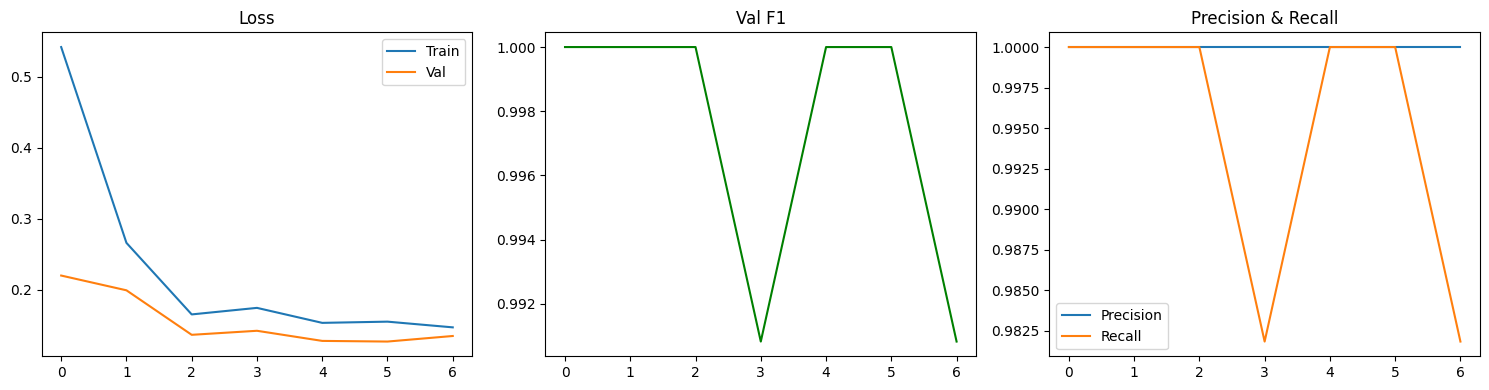

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {'tr_loss':[], 'va_loss':[], 'va_f1':[], 'va_prec':[], 'va_rec':[]}
best_f1, patience_count, PATIENCE = 0.0, 0, 6


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, all_p, all_l = 0, [], []
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(labels)
            all_p.extend(out.argmax(1).cpu().tolist())
            all_l.extend(labels.cpu().tolist())
    n    = len(all_l)
    f1   = f1_score(all_l, all_p, average='binary', pos_label=1, zero_division=0)
    tp   = sum(p==l==1 for p,l in zip(all_p, all_l))
    prec = tp / (sum(p==1 for p in all_p) + 1e-9)
    rec  = tp / (sum(l==1 for l in all_l) + 1e-9)
    return total_loss/n, f1, prec, rec


print(f'{"Ep":>3}  {"Tr Loss":>8}  {"Va Loss":>8}  {"F1":>6}  {"Prec":>6}  {"Rec":>6}  {"LR":>8}')
print('─' * 65)

for epoch in range(1, EPOCHS+1):
    tr_loss, *_         = run_epoch(train_dl, train=True)
    va_loss, f1, pr, rc = run_epoch(val_dl,   train=False)
    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    for k, v in zip(['tr_loss','va_loss','va_f1','va_prec','va_rec'],
                    [tr_loss,   va_loss,  f1,     pr,       rc]):
        history[k].append(v)

    marker = ''
    if f1 > best_f1:
        best_f1 = f1
        patience_count = 0
        torch.save(model.state_dict(), MODEL_PT)
        marker = ' ★'
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'  Early stop at epoch {epoch}')
            break

    print(f'{epoch:3d}  {tr_loss:8.4f}  {va_loss:8.4f}  {f1:6.3f}  {pr:6.3f}  {rc:6.3f}  {lr_now:8.2e}{marker}')

print(f'\nBest val F1: {best_f1:.4f}  →  {MODEL_PT}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['tr_loss'], label='Train')
axes[0].plot(history['va_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['va_f1'], color='green')
axes[1].set_title('Val F1')
axes[2].plot(history['va_prec'], label='Precision')
axes[2].plot(history['va_rec'],  label='Recall')
axes[2].set_title('Precision & Recall'); axes[2].legend()
plt.tight_layout(); plt.savefig('/content/training_curves.png', dpi=130); plt.show()

---
## STEP 8 — Threshold tuning
Finds the decision threshold that maximises F1 on the validation set.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Optimal threshold : 0.49
  F1        : 1.0000
  Precision : 1.0000
  Recall    : 1.0000

Increase threshold → higher precision (fewer false A3s)
Decrease threshold → higher recall    (fewer missed A3s)


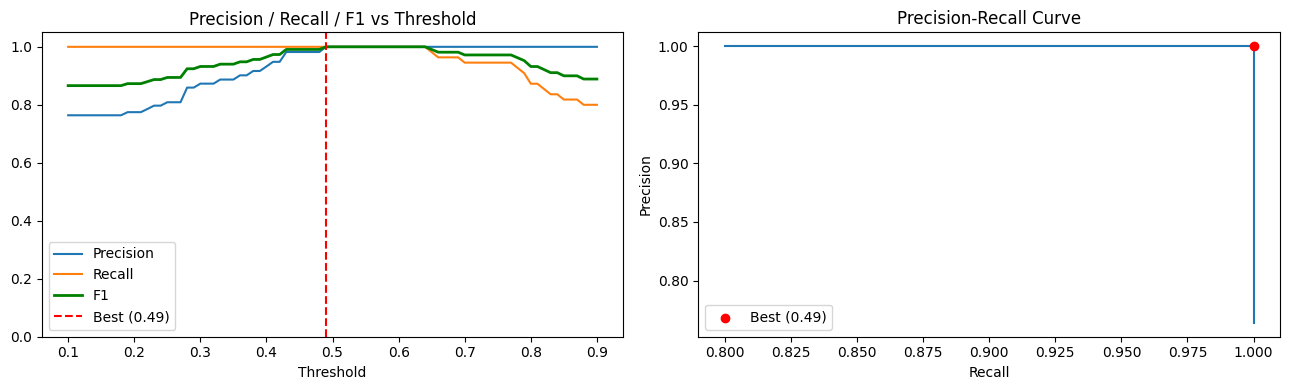

In [10]:
model.load_state_dict(torch.load(MODEL_PT, map_location=DEVICE))
model.eval()

all_probs, all_lbls = [], []
with torch.no_grad():
    for imgs, labels in val_dl:
        probs = F.softmax(model(imgs.to(DEVICE)), dim=1)[:, 1]
        all_probs.extend(probs.cpu().tolist())
        all_lbls.extend(labels.tolist())

all_probs = np.array(all_probs)
all_lbls  = np.array(all_lbls)
thresholds = np.arange(0.10, 0.91, 0.01)
f1s, precs, recs = [], [], []

for t in thresholds:
    preds = (all_probs >= t).astype(int)
    tp = np.sum((preds==1)&(all_lbls==1))
    fp = np.sum((preds==1)&(all_lbls==0))
    fn = np.sum((preds==0)&(all_lbls==1))
    p  = tp/(tp+fp) if (tp+fp) else 0
    r  = tp/(tp+fn) if (tp+fn) else 0
    f  = 2*p*r/(p+r) if (p+r) else 0
    f1s.append(f); precs.append(p); recs.append(r)

best_idx = int(np.argmax(f1s))
BEST_THRESHOLD = float(thresholds[best_idx])
json.dump({'threshold': BEST_THRESHOLD}, open(THRESHOLD_F, 'w'))

print(f'Optimal threshold : {BEST_THRESHOLD:.2f}')
print(f'  F1        : {f1s[best_idx]:.4f}')
print(f'  Precision : {precs[best_idx]:.4f}')
print(f'  Recall    : {recs[best_idx]:.4f}')
print(f'\nIncrease threshold → higher precision (fewer false A3s)')
print(f'Decrease threshold → higher recall    (fewer missed A3s)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thresholds, precs, label='Precision')
axes[0].plot(thresholds, recs,  label='Recall')
axes[0].plot(thresholds, f1s,   label='F1', linewidth=2, color='green')
axes[0].axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'Best ({BEST_THRESHOLD:.2f})')
axes[0].set_xlabel('Threshold'); axes[0].legend(); axes[0].set_ylim(0, 1.05)
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[1].plot(recs, precs)
axes[1].scatter([recs[best_idx]], [precs[best_idx]], color='red', zorder=5,
                label=f'Best ({BEST_THRESHOLD:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()
plt.tight_layout(); plt.savefig('/content/threshold_curve.png', dpi=130); plt.show()

---
## STEP 9 — Test set evaluation

In [11]:
all_probs_t, all_lbls_t = [], []
with torch.no_grad():
    for imgs, labels in test_dl:
        probs = F.softmax(model(imgs.to(DEVICE)), dim=1)[:, 1]
        all_probs_t.extend(probs.cpu().tolist())
        all_lbls_t.extend(labels.tolist())

preds_t = (np.array(all_probs_t) >= BEST_THRESHOLD).astype(int)
lbls_t  = np.array(all_lbls_t)

print('Test Set Results')
print(classification_report(lbls_t, preds_t, target_names=['Other','A3'], digits=4))

cm = confusion_matrix(lbls_t, preds_t)
print('Confusion Matrix (rows=actual, cols=predicted):')
print(f'              Pred:Other  Pred:A3')
print(f'  Actual Other:  {cm[0][0]:6d}   {cm[0][1]:6d}  ← non-A3 sent to A3 folder (bad)')
print(f'  Actual A3:     {cm[1][0]:6d}   {cm[1][1]:6d}  ← A3 missed (bad)')
print(f'\nROC AUC: {roc_auc_score(lbls_t, all_probs_t):.4f}')

Test Set Results
              precision    recall  f1-score   support

       Other     0.9375    0.8333    0.8824        18
          A3     0.9483    0.9821    0.9649        56

    accuracy                         0.9459        74
   macro avg     0.9429    0.9077    0.9236        74
weighted avg     0.9457    0.9459    0.9448        74

Confusion Matrix (rows=actual, cols=predicted):
              Pred:Other  Pred:A3
  Actual Other:      15        3  ← non-A3 sent to A3 folder (bad)
  Actual A3:          1       55  ← A3 missed (bad)

ROC AUC: 0.9702


---
## STEP 10 — Export to ONNX

In [12]:
import time

model.eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

try:
  batch_dim = torch.export.Dim('batch', min=1, max=64)
  torch.onnx.export(
      model, dummy, MODEL_ONNX,
      export_params=True, opset_version=18, do_constant_folding=True,
      input_names=['image'], output_names=['logits'],
      dynamic_axes={'image': {0: batch_dim}, 'logits': {0: 'batch'}},
  )
except Exception as e:
  # Fallback static shape export
  print(f'dynamic_shapes export failed → {e} fallback to static shape')
  torch.onnx.export(
      model, dummy, MODEL_ONNX,
      export_params=True, opset_version=18, do_constant_folding=True,
      input_names=['image'], output_names=['logits'],
      verbose=False,
  )
onnx.checker.check_model(onnx.load(MODEL_ONNX))

size_mb = os.path.getsize(MODEL_ONNX) / 1e6
print(f'ONNX exported → {MODEL_ONNX}  ({size_mb:.1f} MB)')

# Speed benchmark
sess = ort.InferenceSession(MODEL_ONNX, providers=['CPUExecutionProvider'])
dummy_np = dummy.cpu().numpy()
N = 50

t0 = time.perf_counter()
for _ in range(N): model.cpu()(dummy.cpu())
pt_ms = (time.perf_counter()-t0)/N*1000

t0 = time.perf_counter()
for _ in range(N): sess.run(None, {'image': dummy_np})
onnx_ms = (time.perf_counter()-t0)/N*1000

model.to(DEVICE)
print(f'\nCPU inference speed (per image):')
print(f'  PyTorch     : {pt_ms:.1f} ms')
print(f'  ONNX Runtime: {onnx_ms:.1f} ms  ({pt_ms/onnx_ms:.1f}× faster)')

/tmp/ipykernel_211/3460692780.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0311 06:57:25.956000 211 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0311 06:57:25.958000 211 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0311 06:57:25.962000 211 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). 

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 99 of general pattern rewrite rules.
ONNX exported → /content/nssf_efficientnet.onnx  (0.6 MB)

CPU inference speed (per image):
  PyTorch     : 64.5 ms
  ONNX Runtime: 38.7 ms  (1.7× faster)


---
## STEP 11 — Hybrid classifier + final batch sort

In [13]:
# ── Load ONNX session and threshold ──────────────────────────────────────────
_sess      = ort.InferenceSession(MODEL_ONNX,
                providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
_threshold = json.load(open(THRESHOLD_F))['threshold']
_infer_tf  = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN, STD_NORM)])

def onnx_classify(img_pil):
    x      = _infer_tf(img_pil.convert('RGB')).unsqueeze(0).numpy()
    logits = _sess.run(None, {'image': x})[0][0]
    exp    = np.exp(logits - logits.max())
    p_a3   = float(exp[1] / exp.sum())
    return ('A3' if p_a3 >= _threshold else 'Other'), p_a3


def hybrid_classify(image_path, debug=False):
    """
    Returns (label, method, detail, rotation_deg)
    Methods: both_agree | algo_high | cnn_override | review_required
    """
    algo_lbl, algo_conf, img_c, rot = algorithm_classify(image_path)
    cnn_lbl, p_a3 = onnx_classify(img_c if img_c else Image.open(image_path))

    if debug:
        print(f'  Algo: {algo_lbl} ({algo_conf})  |  CNN: {cnn_lbl} (P(A3)={p_a3:.3f})')

    if algo_lbl == cnn_lbl:
        return algo_lbl, 'both_agree',   f'p={p_a3:.2f}', rot

    if algo_conf == 'high':
        return algo_lbl, 'review_required', \
               f'algo={algo_lbl}(high) cnn={cnn_lbl}(p={p_a3:.2f})', rot

    return cnn_lbl, 'cnn_override', \
           f'algo={algo_lbl}(low) cnn={cnn_lbl}(p={p_a3:.2f})', rot


print(f'Hybrid classifier ready  (threshold={_threshold:.2f})')

Hybrid classifier ready  (threshold=0.49)


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [14]:
# ── Final sort ────────────────────────────────────────────────────────────────
FINAL_A3     = '/content/Final_A3'
FINAL_OTHER  = '/content/Final_Other'
FINAL_REVIEW = '/content/Final_Review'
FINAL_REPORT = '/content/final_report.csv'

for d in [FINAL_A3, FINAL_OTHER, FINAL_REVIEW]:
    os.makedirs(d, exist_ok=True)

def final_sort_one(image_path):
    try:
        label, method, detail, rot = hybrid_classify(str(image_path))
        dest_dir = FINAL_REVIEW if method == 'review_required' else \
                   FINAL_A3    if label  == 'A3'               else FINAL_OTHER
        dest = os.path.join(dest_dir, image_path.name)
        if os.path.exists(dest):
            base, ext = os.path.splitext(image_path.name)
            dest = os.path.join(dest_dir, f'{base}_dup{ext}')
        if rot != 0:
            with Image.open(str(image_path)) as img:
                img.rotate(-rot, expand=True).save(dest, quality=SAVE_QUALITY)
        else:
            shutil.copy2(str(image_path), dest)
        return [str(image_path), label, method, rot, detail]
    except Exception as e:
        return [str(image_path), 'Error', 'exception', 0, str(e)]


files = [f for f in Path(SOURCE_DIR).rglob('*') if f.suffix.lower() in EXTS]
print(f'Sorting {len(files)} files with hybrid classifier...\n')

results = [final_sort_one(f) for f in files]

counts  = Counter(r[1] for r in results)
methods = Counter(r[2] for r in results)
rotated = sum(1 for r in results if r[3] != 0)
total   = len(results)

print('── Final Results ─────────────────────────────────────')
for lbl in ['A3','Other','Error']:
    n = counts.get(lbl, 0)
    print(f'  {lbl:12s}: {n:5d}  ({n/total*100:.1f}%)')
print('\n── Decision method breakdown ──')
for m, n in methods.most_common():
    print(f'  {m:30s}: {n:5d}  ({n/total*100:.1f}%)')
review_n = methods.get('review_required', 0)
print(f'\n  ⚠ Manual review needed : {review_n} files → {FINAL_REVIEW}')
print(f'Rotation corrected   : {rotated} files')

with open(FINAL_REPORT, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['File','Label','Method','Rotated_deg','Detail'])
    w.writerows(results)
print(f'\nReport → {FINAL_REPORT}')

Sorting 483 files with hybrid classifier...

── Final Results ─────────────────────────────────────
  A3          :   369  (76.4%)
  Other       :    34  (7.0%)
  Error       :     0  (0.0%)

── Decision method breakdown ──
  both_agree                    :   397  (82.2%)
  review_required               :    82  (17.0%)
  cnn_override                  :     4  (0.8%)

  ⚠ Manual review needed : 82 files → /content/Final_Review
Rotation corrected   : 300 files

Report → /content/final_report.csv


---
## STEP 12 — Active learning: retrain with corrections

Each correction cycle makes the model better and reduces the review count.

In [15]:
print("""
RETRAINING WORKFLOW (run after correcting Review folder)

1. Open /content/Final_Review — check each file visually.
2. Move A3 files  → /content/Sorted_A3
   Move Other files → /content/Sorted_Other

3. Delete the old dataset splits so they get rebuilt:
     !rm -rf /content/dataset

4. Re-run STEP 5 (splits) — it will now include the new corrections.

5. Fine-tune with lower LR (gentler update on existing knowledge):
     model.load_state_dict(torch.load(MODEL_PT))          # load best checkpoint
     for p in model.parameters(): p.requires_grad = True  # unfreeze all
     # Change at top of STEP 7:  LR = 5e-5,  EPOCHS = 10
     # Then re-run STEPS 6 (DataLoaders only), 7, 8, 9, 10

Expected improvement per cycle:
  Baseline            : ~90-94% F1 (algorithm labels only)
  After cycle 1 (50+) : +2-4%  F1,  review count drops ~50%
  After cycle 2 (50+) : +1-2%  F1,  review count → near 0
""")


RETRAINING WORKFLOW (run after correcting Review folder)

1. Open /content/Final_Review — check each file visually.
2. Move A3 files  → /content/Sorted_A3
   Move Other files → /content/Sorted_Other

3. Delete the old dataset splits so they get rebuilt:
     !rm -rf /content/dataset

4. Re-run STEP 5 (splits) — it will now include the new corrections.

5. Fine-tune with lower LR (gentler update on existing knowledge):
     model.load_state_dict(torch.load(MODEL_PT))          # load best checkpoint
     for p in model.parameters(): p.requires_grad = True  # unfreeze all
     # Change at top of STEP 7:  LR = 5e-5,  EPOCHS = 10
     # Then re-run STEPS 6 (DataLoaders only), 7, 8, 9, 10

Expected improvement per cycle:
  Baseline            : ~90-94% F1 (algorithm labels only)
  After cycle 1 (50+) : +2-4%  F1,  review count drops ~50%
  After cycle 2 (50+) : +1-2%  F1,  review count → near 0

